In [31]:
import math
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [32]:
CAPITALS = {
    "Beijing":         (39.9042, 116.4074),
    "Tianjin":         (39.3434, 117.3616),
    "Hebei":           (38.0428, 114.5149),
    "Shanxi":          (37.8706, 112.5489),
    "Inner Mongolia":  (40.8175, 111.7655),
    "Liaoning":        (41.8057, 123.4315),
    "Jilin":           (43.8868, 125.3245),
    "Heilongjiang":    (45.8038, 126.5349),
    "Shanghai":        (31.2304, 121.4737),
    "Jiangsu":         (32.0603, 118.7969),
    "Zhejiang":        (30.2741, 120.1551),
    "Anhui":           (31.8612, 117.2830),
    "Fujian":          (26.0745, 119.2965),
    "Jiangxi":         (28.6820, 115.8579),
    "Shandong":        (36.6512, 117.1201),
    "Henan":           (34.7466, 113.6254),
    "Hubei":           (30.5928, 114.3055),
    "Hunan":           (28.2278, 112.9388),
    "Guangdong":       (23.1291, 113.2644),
    "Guangxi":         (22.8170, 108.3665),
    "Hainan":          (20.0440, 110.3419),
    "Chongqing":       (29.5630, 106.5516),
    "Sichuan":         (30.5723, 104.0665),
    "Guizhou":         (26.5983, 106.7072),
    "Yunnan":          (25.0453, 102.7097),
    "Tibet":           (29.6520,  91.1721),
    "Shaanxi":         (34.2658, 108.9541),
    "Gansu":           (36.0611, 103.8343),
    "Qinghai":         (36.6232, 101.7782),
    "Ningxia":         (38.4872, 106.2309),
    "Xinjiang":        (43.7928,  87.6271),
}

corridors = {
    "G1":  ["Beijing", "Tianjin", "Hebei", "Liaoning", "Jilin", "Heilongjiang"],
    "G2":  ["Beijing", "Tianjin", "Hebei", "Shandong", "Jiangsu", "Shanghai"],
    "G3":  ["Beijing", "Tianjin", "Hebei", "Shandong", "Jiangsu", "Zhejiang", "Fujian"],
    "G4":  ["Beijing", "Hebei", "Henan", "Hubei", "Hunan", "Guangdong"],
    "G5":  ["Beijing", "Hebei", "Shanxi", "Shaanxi", "Sichuan", "Yunnan"],
    "G6":  ["Beijing", "Hebei", "Shanxi", "Shaanxi", "Gansu", "Qinghai", "Tibet"],
    "G7":  ["Beijing", "Hebei", "Inner Mongolia", "Gansu", "Xinjiang"],
    "G10": ["Heilongjiang", "Inner Mongolia"],
    "G11": ["Heilongjiang", "Jilin", "Liaoning"],
    "G12": ["Jilin", "Inner Mongolia"],
    "G15": ["Shandong", "Jiangsu", "Shanghai", "Zhejiang", "Fujian", "Guangdong", "Hainan"],
    "G16": ["Liaoning", "Inner Mongolia"],
    "G18": ["Shandong", "Hebei", "Shanxi", "Shaanxi", "Ningxia", "Inner Mongolia"],
    "G20": ["Shandong", "Hebei", "Shanxi", "Shaanxi", "Ningxia"],
    "G22": ["Shandong", "Henan", "Shanxi", "Shaanxi", "Gansu"],
    "G25": ["Jilin", "Liaoning", "Hebei", "Shandong", "Jiangsu", "Zhejiang", "Fujian", "Guangdong"],
    "G30": ["Jiangsu", "Anhui", "Henan", "Shaanxi", "Gansu", "Xinjiang"],
    "G35": ["Shandong", "Henan", "Hubei", "Jiangxi", "Guangdong"],
    "G36": ["Jiangsu", "Anhui", "Henan"],
    "G40": ["Shanghai", "Jiangsu", "Anhui", "Henan", "Shaanxi"],
    "G42": ["Shanghai", "Jiangsu", "Anhui", "Hubei", "Chongqing", "Sichuan"],
    "G45": ["Heilongjiang", "Inner Mongolia", "Hebei", "Henan", "Hubei", "Jiangxi", "Guangdong"],
    "G50": ["Shanghai", "Zhejiang", "Anhui", "Hubei", "Chongqing"],
    "G55": ["Inner Mongolia", "Shanxi", "Henan", "Hubei", "Hunan", "Guangdong"],
    "G56": ["Zhejiang", "Jiangxi", "Hunan", "Guizhou", "Yunnan"],
    "G59": ["Inner Mongolia", "Shaanxi", "Chongqing", "Guizhou", "Guangxi"],
    "G60": ["Shanghai", "Zhejiang", "Jiangxi", "Hunan", "Guizhou", "Yunnan"],
    "G65": ["Inner Mongolia", "Shaanxi", "Chongqing", "Hunan", "Guangdong"],
    "G69": ["Ningxia", "Gansu", "Sichuan", "Guizhou", "Guangxi"],
    "G70": ["Fujian", "Jiangxi", "Hubei", "Shaanxi", "Ningxia", "Gansu"],
    "G72": ["Fujian", "Jiangxi", "Hunan", "Guangxi"],
    "G75": ["Gansu", "Sichuan", "Chongqing", "Guizhou", "Guangxi", "Guangdong", "Hainan"],
    "G76": ["Fujian", "Guangdong", "Jiangxi", "Hunan", "Guizhou", "Chongqing", "Sichuan"],
    "G78": ["Guangdong", "Guangxi", "Guizhou", "Yunnan"],
    "G80": ["Guangdong", "Guangxi", "Yunnan"],
    "G85": ["Ningxia", "Gansu", "Chongqing", "Guizhou", "Yunnan"],
    "G92": ["Shanghai", "Zhejiang"],
    "G93": ["Sichuan", "Chongqing"],
    "G95": ["Beijing", "Hebei", "Tianjin"],
}

In [33]:
TORTUOSITY = 1.3

def haversine(p1, p2):
    R = 6371.0
    lat1, lon1 = math.radians(p1[0]), math.radians(p1[1])
    lat2, lon2 = math.radians(p2[0]), math.radians(p2[1])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(a))

pairs = {}
for route, provinces in corridors.items():
    for a, b in zip(provinces, provinces[1:]):
        key = tuple(sorted([a, b]))
        if key not in pairs:
            hav = haversine(CAPITALS[a], CAPITALS[b])
            pairs[key] = {"haversine_km": round(hav, 1), "road_est_km": round(hav * TORTUOSITY, 1), "routes": [route]}
        else:
            pairs[key]["routes"].append(route)

df = pd.DataFrame(
    [{"province_a": a, "province_b": b, **v, "routes": ", ".join(sorted(v["routes"]))}
     for (a, b), v in pairs.items()]
).sort_values("road_est_km").reset_index(drop=True)

df

,province_a,province_b,haversine_km,road_est_km,routes
0,Beijing,Tianjin,102.8,133.6,"G1, G2, G3"
1,Anhui,Jiangsu,144.5,187.9,"G30, G36, G40, G42"
2,Shanghai,Zhejiang,164.9,214.3,"G15, G50, G60, G92"
3,Hebei,Shanxi,173.4,225.5,"G18, G20, G5, G6"
4,Gansu,Qinghai,194.5,252.8,G6
...,...,...,...,...,...
58,Inner Mongolia,Liaoning,979.8,1273.7,G16
59,Inner Mongolia,Jilin,1163.7,1512.9,G12
60,Qinghai,Tibet,1254.0,1630.2,G6
61,Heilongjiang,Inner Mongolia,1314.7,1709.1,"G10, G45"


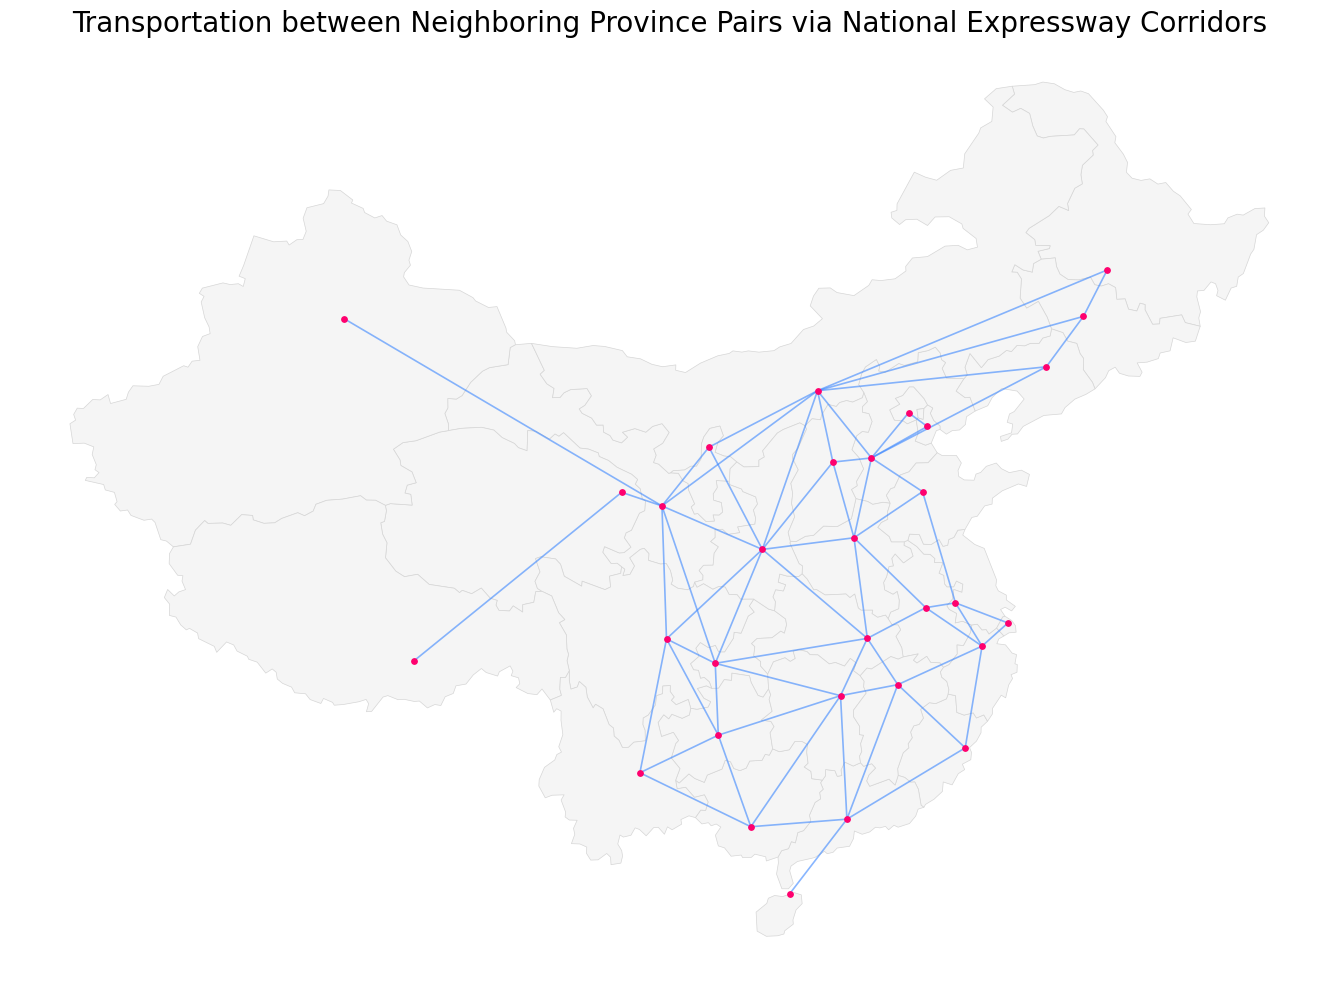

In [35]:
gdf = gpd.read_file("gadm36_CHN_1.json")
gdf["NAME_1"] = gdf["NAME_1"].replace({
    "Nei Mongol": "Inner Mongolia", "Xizang": "Tibet",
    "Ningxia Hui": "Ningxia", "Xinjiang Uygur": "Xinjiang",
})

fig, ax = plt.subplots(figsize=(15, 10))
gdf.plot(ax=ax, color="#f5f5f5", edgecolor="#d6d6d6", linewidth=0.5)

for _, row in df.iterrows():
    lat1, lon1 = CAPITALS[row["province_a"]]
    lat2, lon2 = CAPITALS[row["province_b"]]
    ax.plot([lon1, lon2], [lat1, lat2], color="#3a86ff", linewidth=1.2, alpha=0.6, zorder=3)

for lat, lon in CAPITALS.values():
    ax.scatter(lon, lat, s=15, color="#ff006e", zorder=4)

ax.set_title("Transportation between Neighboring Province Pairs via National Expressway Corridors", fontsize=20)
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [42]:
import json
import os

commodity = "CrudeSteel"
commodity_prefix = commodity.lower()
cost_per_ton_per_km = 0.034

REGION_MAP = {
    "Beijing":         "Region1Beijing",
    "Tianjin":         "Region2Tianjin",
    "Hebei":           "Region3Hebei",
    "Shanxi":          "Region4Shanxi",
    "Inner Mongolia":  "Region5Innermongolia",
    "Liaoning":        "Region6Liaoning",
    "Jilin":           "Region7Jilin",
    "Heilongjiang":    "Region8Heilongjiang",
    "Shanghai":        "Region9Shanghai",
    "Jiangsu":         "Region10Jiangsu",
    "Zhejiang":        "Region11Zhejiang",
    "Anhui":           "Region12Anhui",
    "Fujian":          "Region13Fujian",
    "Jiangxi":         "Region14Jiangxi",
    "Shandong":        "Region15Shandong",
    "Henan":           "Region16Henan",
    "Hubei":           "Region17Hubei",
    "Hunan":           "Region18Hunan",
    "Guangdong":       "Region19Guangdong",
    "Guangxi":         "Region20Guangxi",
    "Hainan":          "Region21Hainan",
    "Chongqing":       "Region22Chongqing",
    "Sichuan":         "Region23Sichuan",
    "Guizhou":         "Region24Guizhou",
    "Yunnan":          "Region25Yunnan",
    "Tibet":           "Region26Tibet",
    "Shaanxi":         "Region27Shaanxi",
    "Gansu":           "Region28Gansu",
    "Qinghai":         "Region29Qinghai",
    "Ningxia":         "Region30Ningxia",
    "Xinjiang":        "Region31Xinjiang",
}

output_path = (
    "/Users/al3792/Documents_Local/MacroEnergy.jl/"
    "ExampleSystems/31_provinces_1_period_updatedelec_steel_cement_aluminum_288/"
    f"assets/assets_1/{commodity_prefix}_transport.json"
)

In [43]:
def make_transport_json(commodity, commodity_prefix, cost_per_ton_per_km, province_pair_distances):
    instances = []
    for (origin, destination), distance_km in province_pair_distances.items():
        variable_om_cost = round(cost_per_ton_per_km * distance_km, 4)
        instances.append({
            "id": f"{commodity_prefix}_transport_{origin}_to_{destination}",
            "edges": {
                "transmission_edge": {
                    "start_vertex": f"{commodity_prefix}_{origin}",
                    "end_vertex":   f"{commodity_prefix}_{destination}",
                    "variable_om_cost": variable_om_cost,
                }
            },
        })
    return {
        "transmission": {
            "global_data": {
                "transforms": {},
                "edges": {
                    "transmission_edge": {
                        "unidirectional": True,
                        "has_capacity": False,
                        "commodity": commodity,
                        "loss_fraction": 0,
                    }
                },
            },
            "instance_data": instances,
        }
    }


# Build bidirectional pairs from df using road_est_km distances
province_pair_distances = {}
for _, row in df.iterrows():
    a, b = REGION_MAP[row["province_a"]], REGION_MAP[row["province_b"]]
    province_pair_distances[(a, b)] = row["road_est_km"]
    province_pair_distances[(b, a)] = row["road_est_km"]

data = make_transport_json(
    commodity=commodity,
    commodity_prefix=commodity_prefix,
    cost_per_ton_per_km=cost_per_ton_per_km,
    province_pair_distances=province_pair_distances,
)

os.makedirs(os.path.dirname(output_path), exist_ok=True)
with open(output_path, "w") as f:
    json.dump(data, f, indent=2)

print(f"Wrote {len(province_pair_distances)} transport links ({len(df)} pairs × 2 directions) to:")
print(output_path)

# Preview first 5 entries
preview = {
    "transmission": {
        "global_data": data["transmission"]["global_data"],
        "instance_data": data["transmission"]["instance_data"][:5],
    }
}
print(json.dumps(preview, indent=2))

Wrote 126 transport links (63 pairs × 2 directions) to:
/Users/al3792/Documents_Local/MacroEnergy.jl/ExampleSystems/31_provinces_1_period_updatedelec_steel_cement_aluminum_288/assets/assets_1/crudesteel_transport.json
{
  "transmission": {
    "global_data": {
      "transforms": {},
      "edges": {
        "transmission_edge": {
          "unidirectional": true,
          "has_capacity": false,
          "commodity": "CrudeSteel",
          "loss_fraction": 0
        }
      }
    },
    "instance_data": [
      {
        "id": "crudesteel_transport_Region1Beijing_to_Region2Tianjin",
        "edges": {
          "transmission_edge": {
            "start_vertex": "crudesteel_Region1Beijing",
            "end_vertex": "crudesteel_Region2Tianjin",
            "variable_om_cost": 4.5424
          }
        }
      },
      {
        "id": "crudesteel_transport_Region2Tianjin_to_Region1Beijing",
        "edges": {
          "transmission_edge": {
            "start_vertex": "crudesteel_Re